In [1]:
from datasets import load_from_disk
import numpy as np
import os
import torch
from scipy.special import log_softmax, softmax
import matplotlib.pyplot as plt
from expected_cost.utils import plot_hists

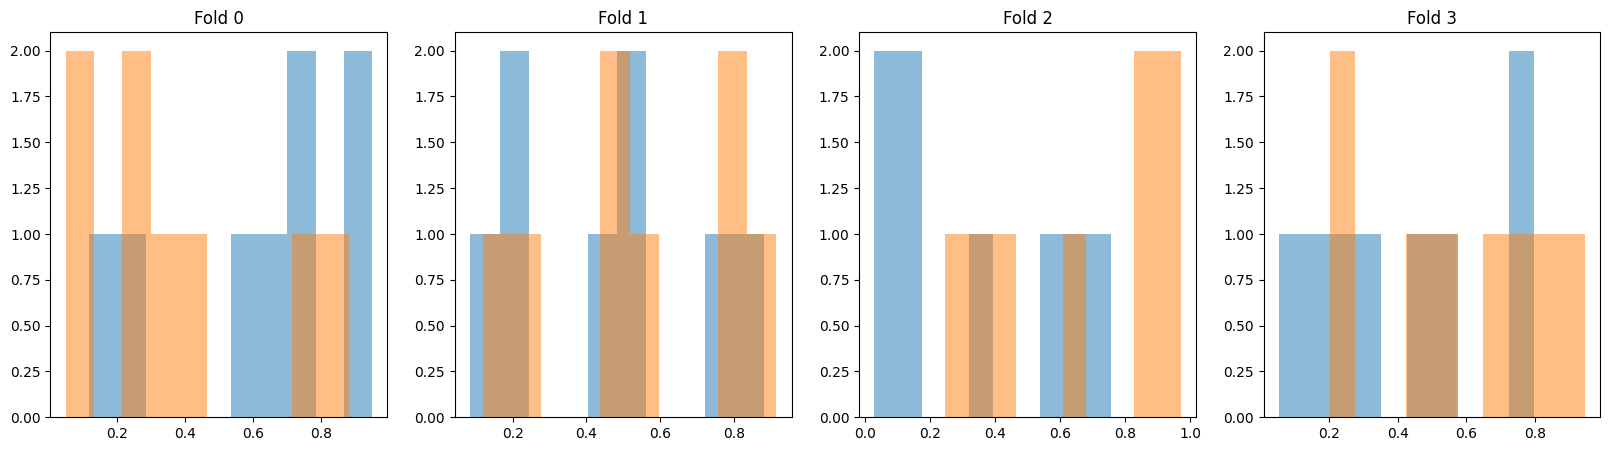

In [20]:
# experiment_path = "../experiments/sst2_8_639/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_xval_10samples/.cache"
experiment_path = "../experiments/sst2_16_564/basic_sst2_0-shot_litgpt/lm_tinyllama/lora_xval_20samples/.cache"
# experiment_path = "../experiments/dbpedia_4_926/basic_dbpedia_0-shot_litgpt/lm_tinyllama/lora_xval_60samples/.cache"

# ckpt = torch.load(os.path.join(experiment_path, "fold_0/last.ckpt"))
# plot_hists(targets, logprobs, outfile=None, nbins=4, group_by='score', style='-', label_prefix='', axs=None)
nfolds = 4
fig, ax = plt.subplots(1, nfolds, figsize=(20, 5))
for f in range(nfolds):
    data = load_from_disk(os.path.join(experiment_path, f"fold_{f}/predictions")).with_format("numpy")
    # scores = log_softmax(data["logits"], axis=1)
    scores = softmax(data["logits"], axis=1)
    targets = data["label"]
    for i in range(scores.shape[1]):
        ax[f].hist(scores[:, i], bins=10, alpha=0.5, label=f"class {i}")
    ax[f].set_title(f"Fold {f}")